# NIFTY 50 Forecasting — Step 1: Data Collection & Technical Indicators
**Project:** Multi-model time series forecasting (ARIMA + Prophet + LSTM)  
**Data:** NIFTY 50 Index via yfinance (`^NSEI`)  
**Goal of this notebook:** Fetch 5 years of NIFTY data, add RSI, MACD, Bollinger Bands, and save a clean dataset for modelling.

---

## 0. Install dependencies
Run this cell once, then restart kernel.

In [13]:
# Run once to install
# !pip install yfinance pandas numpy matplotlib seaborn ta scikit-learn --quiet

## 1. Import libraries

In [14]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn ta scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ta = Technical Analysis library (handles RSI, MACD, Bollinger Bands)
import ta

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Fetch NIFTY 50 data from Yahoo Finance

**Ticker symbol:** `^NSEI` → NIFTY 50 on Yahoo Finance  
**Also useful:**  
- `^NSEBANK` → BANKNIFTY  
- `^NSEMDCP50` → NIFTY Midcap 50  
- `RELIANCE.NS`, `HDFCBANK.NS` → Individual NSE stocks (add `.NS` suffix)

In [16]:
TICKER   = '^NSEI'       # NIFTY 50
START    = '2019-01-01'  # 5 years of data — enough for all 3 models
END      = '2024-12-31'

print(f'Downloading {TICKER} from {START} to {END}...')
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)

# Flatten MultiIndex columns if present (yfinance v0.2+)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

print(f'Shape: {raw.shape}')
print(f'Date range: {raw.index[0].date()} → {raw.index[-1].date()}')
print(f'Missing values: {raw.isnull().sum().sum()}')
raw.tail(5)

[*********************100%***********************]  1 of 1 completed

Shape: (1477, 5)
Date range: 2019-01-02 → 2024-12-30
Missing values: 0


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-12-23,23753.449219,23869.550781,23647.199219,23738.199219,189800
2024-12-24,23727.650391,23867.650391,23685.150391,23769.099609,177700
2024-12-26,23750.199219,23854.500000,23653.599609,23775.800781,177700
2024-12-27,23813.400391,23938.849609,23800.599609,23801.400391,176800
2024-12-30,23644.900391,23915.349609,23599.300781,23796.900391,364900


## 3. Basic data cleaning

In [17]:
df = raw.copy()

# Keep only OHLCV columns
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Forward-fill any missing trading day gaps (rare for NIFTY)
df = df.ffill()

# Remove rows where Close is 0 or NaN (data errors)
df = df[df['Close'] > 0].copy()

# Add useful time features
df['Year']      = df.index.year
df['Month']     = df.index.month
df['DayOfWeek'] = df.index.dayofweek   # 0=Monday, 4=Friday
df['Quarter']   = df.index.quarter
df['WeekOfYear']= df.index.isocalendar().week.astype(int)

# Daily return
df['Daily_Return'] = df['Close'].pct_change() * 100

# Log return (better for modelling — stabilises variance)
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

print(f'Clean dataset shape: {df.shape}')
df.head(3)

Clean dataset shape: (1477, 12)


Price,Open,High,Low,Close,Volume,Year,Month,DayOfWeek,Quarter,WeekOfYear,Daily_Return,Log_Return
Date,,,,,,,,,,,,
2019-01-02,10868.849609,10895.349609,10735.049805,10792.500000,309700,2019,1,2,1,1,NaN,NaN
2019-01-03,10796.799805,10814.049805,10661.250000,10672.250000,286200,2019,1,3,1,1,-1.114200,-0.011205
2019-01-04,10699.700195,10741.049805,10628.650391,10727.349609,296600,2019,1,4,1,1,0.516289,0.005150


## 4. Technical Indicators

We'll add the 3 most important indicators for trading systems:
- **RSI** — momentum oscillator, shows overbought/oversold
- **MACD** — trend-following momentum indicator
- **Bollinger Bands** — volatility bands around a moving average

Plus basic moving averages (SMA, EMA) used as features in LSTM.

In [18]:
# ── Moving Averages ──────────────────────────────────────────────────────────
df['SMA_20']  = df['Close'].rolling(window=20).mean()   # 20-day Simple MA
df['SMA_50']  = df['Close'].rolling(window=50).mean()   # 50-day Simple MA
df['SMA_200'] = df['Close'].rolling(window=200).mean()  # 200-day Simple MA (golden cross)
df['EMA_12']  = df['Close'].ewm(span=12, adjust=False).mean()  # Fast EMA
df['EMA_26']  = df['Close'].ewm(span=26, adjust=False).mean()  # Slow EMA

# ── RSI (14-period) ──────────────────────────────────────────────────────────
# RSI > 70 → overbought, RSI < 30 → oversold
rsi_indicator = ta.momentum.RSIIndicator(close=df['Close'], window=14)
df['RSI_14'] = rsi_indicator.rsi()

# ── MACD ─────────────────────────────────────────────────────────────────────
# MACD Line = EMA(12) - EMA(26)
# Signal Line = EMA(9) of MACD Line
# Histogram = MACD Line - Signal Line
macd_indicator = ta.trend.MACD(close=df['Close'],
                                window_slow=26,
                                window_fast=12,
                                window_sign=9)
df['MACD']        = macd_indicator.macd()
df['MACD_Signal'] = macd_indicator.macd_signal()
df['MACD_Hist']   = macd_indicator.macd_diff()

# ── Bollinger Bands (20-day, 2 std dev) ──────────────────────────────────────
bb_indicator = ta.volatility.BollingerBands(close=df['Close'],
                                             window=20,
                                             window_dev=2)
df['BB_Upper']  = bb_indicator.bollinger_hband()   # Upper band
df['BB_Middle'] = bb_indicator.bollinger_mavg()    # Middle band (= SMA_20)
df['BB_Lower']  = bb_indicator.bollinger_lband()   # Lower band
df['BB_Width']  = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']  # Volatility proxy
df['BB_Pct']    = bb_indicator.bollinger_pband()   # Position within bands (0-1)

# ── ATR (Average True Range) — volatility measure ────────────────────────────
atr_indicator = ta.volatility.AverageTrueRange(high=df['High'],
                                                low=df['Low'],
                                                close=df['Close'],
                                                window=14)
df['ATR_14'] = atr_indicator.average_true_range()

# ── Volume indicators ─────────────────────────────────────────────────────────
df['Volume_SMA_20'] = df['Volume'].rolling(window=20).mean()
df['Volume_Ratio']  = df['Volume'] / df['Volume_SMA_20']   # High = unusual activity

print(f'Dataset with indicators shape: {df.shape}')
print(f'\nNew columns added:')
new_cols = [c for c in df.columns if c not in ['Open','High','Low','Close','Volume']]
print(new_cols)

Dataset with indicators shape: (1477, 29)

New columns added:
['Year', 'Month', 'DayOfWeek', 'Quarter', 'WeekOfYear', 'Daily_Return', 'Log_Return', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'BB_Pct', 'ATR_14', 'Volume_SMA_20', 'Volume_Ratio']


## 5. EDA — Exploratory Data Analysis

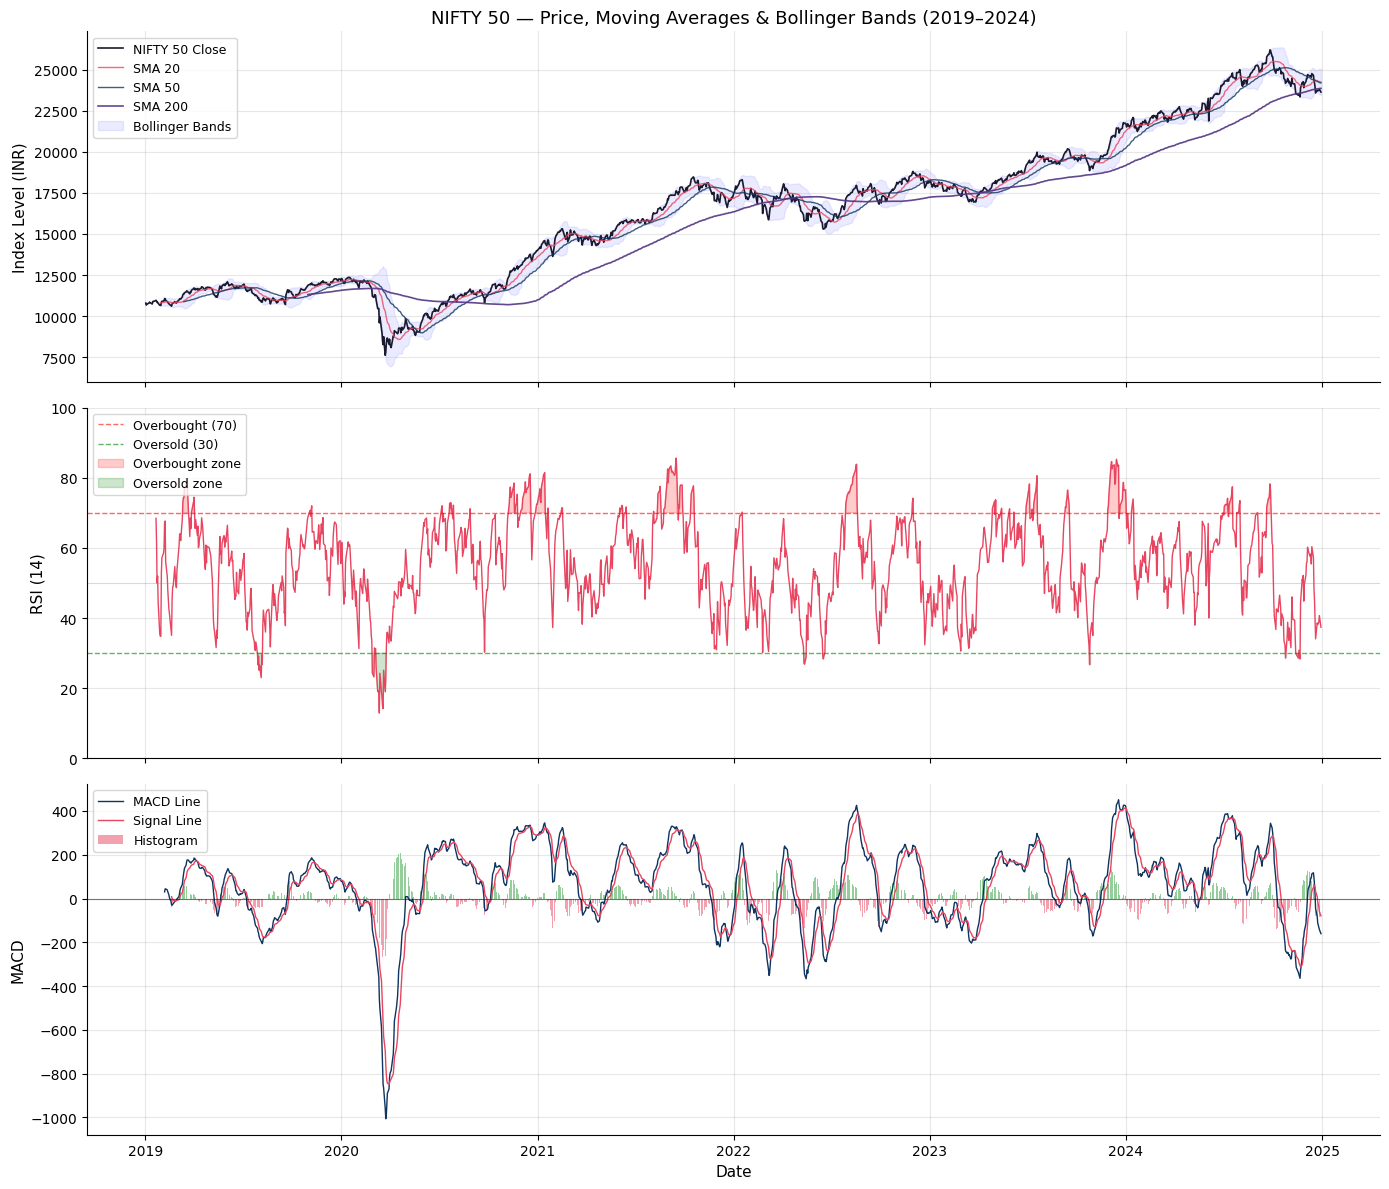

Chart saved as nifty_technical_indicators.png


In [19]:
# ── Plot 1: NIFTY 50 Price with Moving Averages ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price + MAs
ax1 = axes[0]
ax1.plot(df.index, df['Close'],   color='#1a1a2e', linewidth=1.2, label='NIFTY 50 Close')
ax1.plot(df.index, df['SMA_20'],  color='#e94560', linewidth=1,   label='SMA 20',  alpha=0.8)
ax1.plot(df.index, df['SMA_50'],  color='#0f3460', linewidth=1,   label='SMA 50',  alpha=0.8)
ax1.plot(df.index, df['SMA_200'], color='#533483', linewidth=1.2, label='SMA 200', alpha=0.9)
ax1.fill_between(df.index, df['BB_Upper'], df['BB_Lower'],
                 alpha=0.08, color='blue', label='Bollinger Bands')
ax1.set_ylabel('Index Level (INR)', fontsize=11)
ax1.set_title('NIFTY 50 — Price, Moving Averages & Bollinger Bands (2019–2024)', fontsize=13)
ax1.legend(loc='upper left', fontsize=9)

# Panel 2: RSI
ax2 = axes[1]
ax2.plot(df.index, df['RSI_14'], color='#e94560', linewidth=1)
ax2.axhline(70, color='red',   linestyle='--', alpha=0.6, linewidth=1, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.6, linewidth=1, label='Oversold (30)')
ax2.axhline(50, color='gray',  linestyle='-',  alpha=0.3, linewidth=0.8)
ax2.fill_between(df.index, df['RSI_14'], 70,
                 where=(df['RSI_14'] >= 70), alpha=0.2, color='red',   label='Overbought zone')
ax2.fill_between(df.index, df['RSI_14'], 30,
                 where=(df['RSI_14'] <= 30), alpha=0.2, color='green', label='Oversold zone')
ax2.set_ylabel('RSI (14)', fontsize=11)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', fontsize=9)

# Panel 3: MACD
ax3 = axes[2]
ax3.plot(df.index, df['MACD'],        color='#0f3460', linewidth=1,   label='MACD Line')
ax3.plot(df.index, df['MACD_Signal'], color='#e94560', linewidth=1,   label='Signal Line')
colors = ['#2d9c3c' if v >= 0 else '#e94560' for v in df['MACD_Hist']]
ax3.bar(df.index, df['MACD_Hist'], color=colors, alpha=0.5, width=1, label='Histogram')
ax3.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax3.set_ylabel('MACD', fontsize=11)
ax3.set_xlabel('Date', fontsize=11)
ax3.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('nifty_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as nifty_technical_indicators.png')

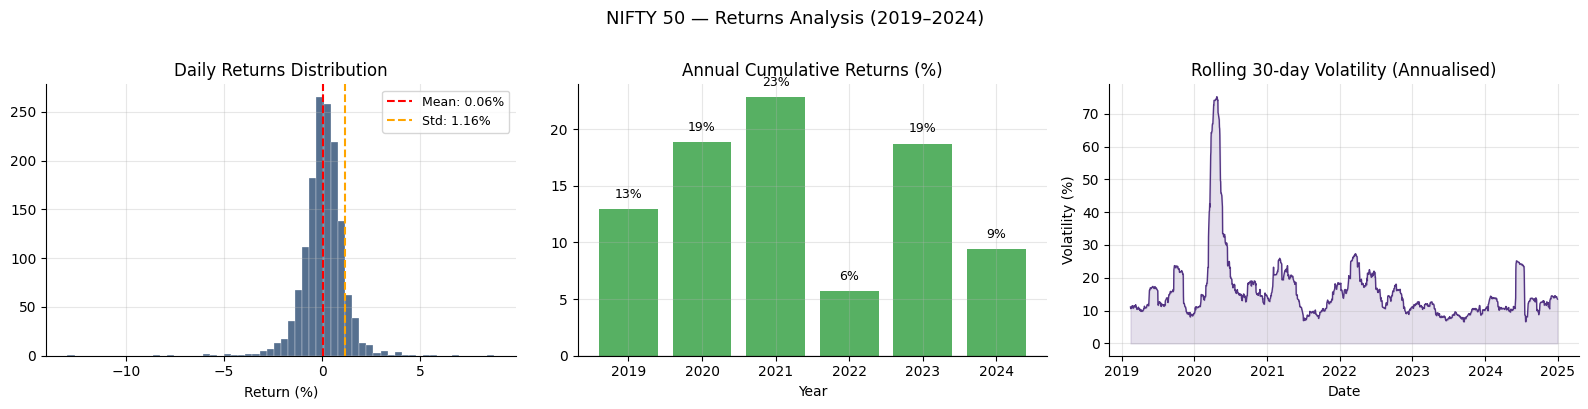

In [20]:
# ── Plot 2: Returns Distribution Analysis ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

clean_returns = df['Daily_Return'].dropna()

# Histogram
axes[0].hist(clean_returns, bins=60, color='#0f3460', alpha=0.7, edgecolor='white', linewidth=0.3)
axes[0].axvline(clean_returns.mean(), color='red',   linestyle='--', label=f'Mean: {clean_returns.mean():.2f}%')
axes[0].axvline(clean_returns.std(),  color='orange',linestyle='--', label=f'Std: {clean_returns.std():.2f}%')
axes[0].set_title('Daily Returns Distribution', fontsize=12)
axes[0].set_xlabel('Return (%)')
axes[0].legend(fontsize=9)

# Annual returns
annual_returns = df.groupby('Year')['Daily_Return'].sum()
colors = ['#2d9c3c' if v > 0 else '#e94560' for v in annual_returns]
axes[1].bar(annual_returns.index.astype(str), annual_returns.values, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Annual Cumulative Returns (%)', fontsize=12)
axes[1].set_xlabel('Year')
for i, (year, val) in enumerate(annual_returns.items()):
    axes[1].text(i, val + (1 if val > 0 else -2), f'{val:.0f}%', ha='center', fontsize=9)

# Rolling volatility (30-day std of returns)
rolling_vol = df['Daily_Return'].rolling(30).std() * np.sqrt(252)  # annualised
axes[2].plot(df.index, rolling_vol, color='#533483', linewidth=1)
axes[2].fill_between(df.index, rolling_vol, alpha=0.15, color='#533483')
axes[2].set_title('Rolling 30-day Volatility (Annualised)', fontsize=12)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Volatility (%)')

plt.suptitle('NIFTY 50 — Returns Analysis (2019–2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('nifty_returns_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

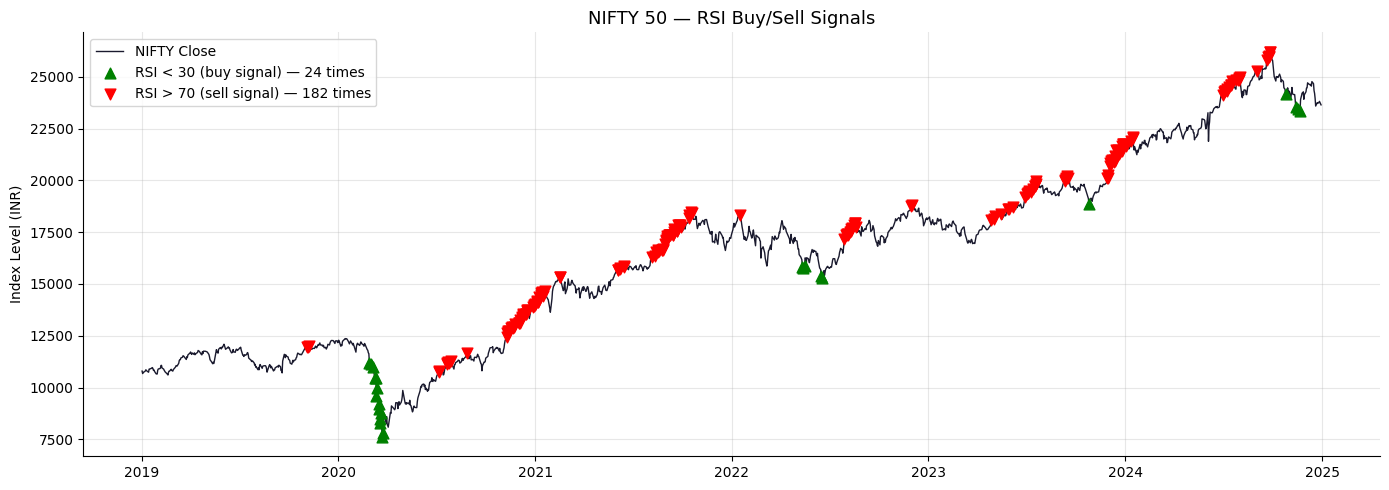


Signal Summary:
  Oversold  (RSI < 30): 24 occurrences
  Overbought (RSI > 70): 182 occurrences


In [21]:
# ── Plot 3: RSI Signal Analysis ───────────────────────────────────────────────
# Find actual buy/sell signals based on RSI
df_signals = df.copy().dropna()

oversold_signals  = df_signals[df_signals['RSI_14'] < 30]
overbought_signals = df_signals[df_signals['RSI_14'] > 70]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='#1a1a2e', linewidth=1, label='NIFTY Close')
ax.scatter(oversold_signals.index,   oversold_signals['Close'],
           color='green', marker='^', s=60, zorder=5, label=f'RSI < 30 (buy signal) — {len(oversold_signals)} times')
ax.scatter(overbought_signals.index, overbought_signals['Close'],
           color='red',   marker='v', s=60, zorder=5, label=f'RSI > 70 (sell signal) — {len(overbought_signals)} times')
ax.set_title('NIFTY 50 — RSI Buy/Sell Signals', fontsize=13)
ax.set_ylabel('Index Level (INR)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('nifty_rsi_signals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSignal Summary:")
print(f"  Oversold  (RSI < 30): {len(oversold_signals)} occurrences")
print(f"  Overbought (RSI > 70): {len(overbought_signals)} occurrences")

## 6. Feature Correlation Analysis

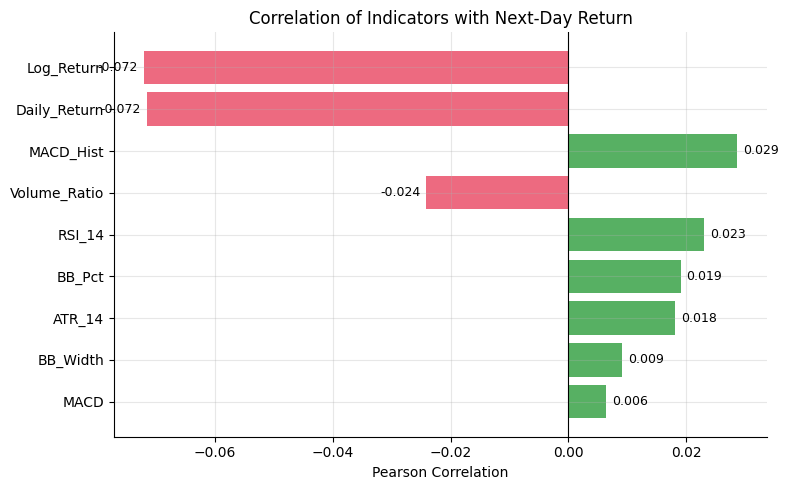


Note: Low correlations are EXPECTED in stock data.
Correlation is not the only measure of predictive power for non-linear models.


In [22]:
# How correlated are our indicators with next-day return?
df_corr = df.copy().dropna()
df_corr['Next_Day_Return'] = df_corr['Daily_Return'].shift(-1)  # target

feature_cols = ['RSI_14', 'MACD', 'MACD_Hist', 'BB_Pct', 'BB_Width',
                'ATR_14', 'Volume_Ratio', 'Daily_Return', 'Log_Return']

corr_with_target = df_corr[feature_cols + ['Next_Day_Return']].corr()['Next_Day_Return'].drop('Next_Day_Return')
corr_with_target = corr_with_target.sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e94560' if v < 0 else '#2d9c3c' for v in corr_with_target]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Indicators with Next-Day Return', fontsize=12)
ax.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('nifty_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Low correlations are EXPECTED in stock data.")
print("Correlation is not the only measure of predictive power for non-linear models.")

## 7. Summary Statistics

In [23]:
print('='*55)
print('   NIFTY 50 — Dataset Summary (2019–2024)')
print('='*55)
print(f"  Total trading days  : {len(df)}")
print(f"  Date range          : {df.index[0].date()} → {df.index[-1].date()}")
print(f"  Starting level      : {df['Close'].iloc[0]:,.0f}")
print(f"  Ending level        : {df['Close'].iloc[-1]:,.0f}")
total_return = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
print(f"  Total return        : {total_return:.1f}%")
print(f"  All-time high       : {df['Close'].max():,.0f}  ({df['Close'].idxmax().date()})")
print(f"  All-time low        : {df['Close'].min():,.0f}  ({df['Close'].idxmin().date()})")
print(f"  Avg daily return    : {df['Daily_Return'].mean():.3f}%")
print(f"  Std daily return    : {df['Daily_Return'].std():.3f}%")
print(f"  Annualised vol      : {df['Daily_Return'].std() * np.sqrt(252):.1f}%")
sharpe = (df['Daily_Return'].mean() * 252) / (df['Daily_Return'].std() * np.sqrt(252))
print(f"  Sharpe ratio (est.) : {sharpe:.2f}")
print(f"  Total features      : {len(df.columns)}")
print('='*55)

   NIFTY 50 — Dataset Summary (2019–2024)
  Total trading days  : 1477
  Date range          : 2019-01-02 → 2024-12-30
  Starting level      : 10,792
  Ending level        : 23,645
  Total return        : 119.1%
  All-time high       : 26,216  (2024-09-26)
  All-time low        : 7,610  (2020-03-23)
  Avg daily return    : 0.060%
  Std daily return    : 1.157%
  Annualised vol      : 18.4%
  Sharpe ratio (est.) : 0.82
  Total features      : 29


## 8. Save clean dataset

In [24]:
# Drop rows with NaN (from rolling window calculations)
df_final = df.dropna().copy()

print(f'Rows before dropna : {len(df)}')
print(f'Rows after dropna  : {len(df_final)}  (lost {len(df) - len(df_final)} rows from indicator warmup)')

# Save
df_final.to_csv('nifty50_with_indicators.csv')
print(f'\nSaved: nifty50_with_indicators.csv')
print(f'Shape: {df_final.shape}')
print(f'\nColumns saved:')
for i, col in enumerate(df_final.columns, 1):
    print(f'  {i:2}. {col}')

Rows before dropna : 1477
Rows after dropna  : 1278  (lost 199 rows from indicator warmup)

Saved: nifty50_with_indicators.csv
Shape: (1278, 29)

Columns saved:
   1. Open
   2. High
   3. Low
   4. Close
   5. Volume
   6. Year
   7. Month
   8. DayOfWeek
   9. Quarter
  10. WeekOfYear
  11. Daily_Return
  12. Log_Return
  13. SMA_20
  14. SMA_50
  15. SMA_200
  16. EMA_12
  17. EMA_26
  18. RSI_14
  19. MACD
  20. MACD_Signal
  21. MACD_Hist
  22. BB_Upper
  23. BB_Middle
  24. BB_Lower
  25. BB_Width
  26. BB_Pct
  27. ATR_14
  28. Volume_SMA_20
  29. Volume_Ratio


---
## What's next?

| Step | Notebook | What you'll build |
|------|----------|-------------------|
| **Step 1** | This notebook ✅ | Data collection, technical indicators, EDA |
| **Step 2** | `step2_arima.ipynb` | Stationarity tests, ARIMA/SARIMA modelling |
| **Step 3** | `step3_prophet.ipynb` | Facebook Prophet with Indian market holidays |
| **Step 4** | `step4_lstm.ipynb` | LSTM with sequence windowing, lag features |
| **Step 5** | `step5_comparison.ipynb` | Model comparison, walk-forward backtest, Sharpe ratio |

**Key question answered by Step 2:** Is the NIFTY 50 price series stationary?  
*(Hint: it's not — you'll need to difference it for ARIMA)*